# Lab3 Henrik

In [98]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import re

In [99]:
url = 'data/Titanic.csv'

In [100]:
df = pd.read_csv(url, sep=",")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [102]:
df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [103]:
df = df.replace(r'^\s*$', np.nan, regex=True)
df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

<Axes: ylabel='Age'>

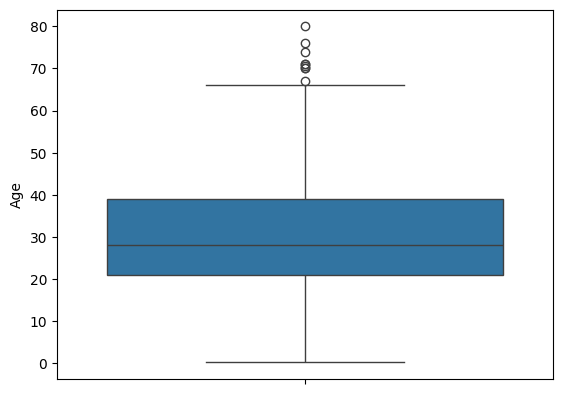

In [104]:
sns.boxplot(df['Age'])

<Axes: xlabel='Age', ylabel='Density'>

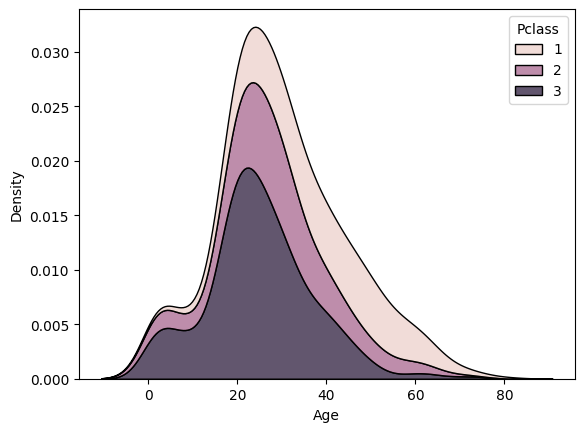

In [105]:
sns.kdeplot(data=df, x='Age', hue='Pclass', multiple='stack')

<Axes: xlabel='Age', ylabel='Density'>

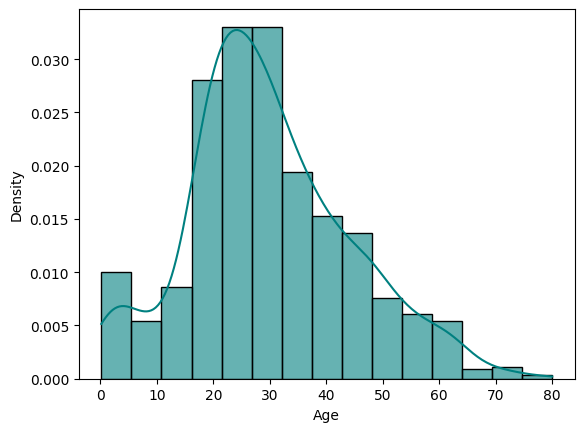

In [106]:
sns.histplot(data=df, x='Age', bins=15, color='teal', alpha=0.6, kde=True, stat='density')

In [107]:
print('Mean of "Age" is:', round(df['Age'].mean(skipna=True),2))
print('Median of "Age" is:', round(df['Age'].median(skipna=True),2))

Mean of "Age" is: 29.88
Median of "Age" is: 28.0


In [108]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [109]:
print('Percent missing in "Cabin" column:', round(((df['Cabin'].isnull().sum()/df.shape[0])*100),2))

Percent missing in "Cabin" column: 77.46


In [110]:
df['HasCabin'] = df.Cabin.notnull()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False


In [111]:
df.groupby(df['Embarked']).count()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,HasCabin
Embarked,,,,,,,,,,,,
C,270,168,270,270,270,270,270,270,270,270,118,270
Q,123,77,123,123,123,123,123,123,123,123,5,123
S,914,644,914,914,914,914,914,914,914,914,170,914


<Axes: xlabel='Embarked', ylabel='count'>

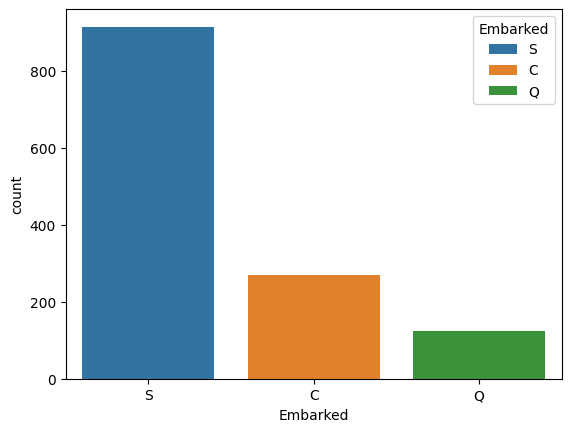

In [112]:
sns.countplot(x='Embarked', data=df, hue='Embarked')

In [113]:
df['Embarked'] = df['Embarked'].fillna('S')

In [114]:
df['Title'] = df.Name.apply(lambda x: re.search(r'([A-Z][a-z]+)\.', x).group(1))

In [115]:
df['Title'].value_counts()

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Major         2
Mlle          2
Ms            2
Mme           1
Don           1
Sir           1
Lady          1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

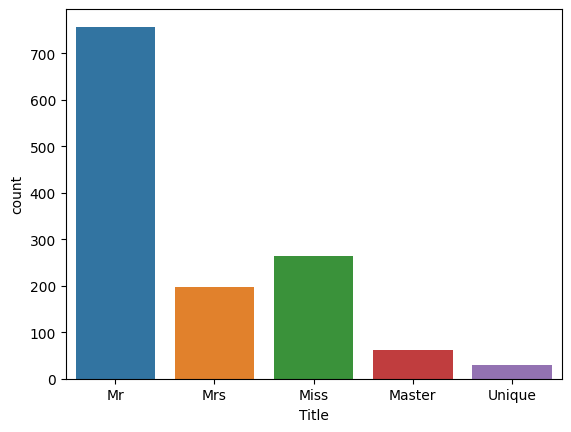

In [116]:
df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Mme':'Mrs', 'Ms':'Miss'})
df['Title'] = df['Title'].replace(['Don', 'Dona', 'Rev', 'Dr', 'Major', 'Lady', 'Sir', 'Col', 'Capt', 'Countess', 'Jonkheer'],'Unique')
sns.countplot(x='Title', data=df, hue='Title');

In [117]:
df['Title'].value_counts()

Title
Mr        757
Miss      264
Mrs       198
Master     61
Unique     29
Name: count, dtype: int64

In [118]:
df.groupby('Title').count()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
Title,,,,,,,,,,,,,
Master,61,40,61,61,61,61,61,61,61,61,9,61,61
Miss,264,185,264,264,264,264,264,264,264,264,60,264,264
Mr,757,517,757,757,757,757,757,757,757,757,135,757,757
Mrs,198,126,198,198,198,198,198,198,198,198,77,198,198
Unique,29,23,29,29,29,29,29,29,29,29,14,29,29


In [119]:
df['CatAge'] = pd.qcut(df['Age'], q=4, labels=False)
df['CatFare'] = pd.qcut(df['Fare'], q=4, labels=False)

In [120]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin,Title,CatAge,CatFare
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,Mr,0,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True,Mrs,3,3
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,Miss,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True,Mrs,2,3
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,Mr,2,1


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1309 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1309 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1309 non-null   object 
 12  HasCabin     1309 non-null   bool   
 13  Title        1309 non-null   object 
 14  CatAge       1309 non-null   int64  
 15  CatFare      1309 non-null   int64  
dtypes: bool(1), float64(3), int64(6), object(6)
memory usage: 154.8+ KB


In [122]:
df = df.drop(['PassengerId', 'Age', 'Fare', 'Cabin', 'Name', 'Ticket'], axis=1)
df.head()

,Survived,Pclass,Sex,SibSp,Parch,Embarked,HasCabin,Title,CatAge,CatFare
0,0.0,3,male,1,0,S,False,Mr,0,0
1,1.0,1,female,1,0,C,True,Mrs,3,3
2,1.0,3,female,0,0,S,False,Miss,1,1
3,1.0,1,female,1,0,S,True,Mrs,2,3
4,0.0,3,male,0,0,S,False,Mr,2,1


In [123]:
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy.head()

,Survived,Pclass,SibSp,Parch,HasCabin,CatAge,CatFare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Unique
0,0.0,3,1,0,False,0,0,True,False,True,False,True,False,False
1,1.0,1,1,0,True,3,3,False,False,False,False,False,True,False
2,1.0,3,0,0,False,1,1,False,False,True,True,False,False,False
3,1.0,1,1,0,True,2,3,False,False,True,False,False,True,False
4,0.0,3,0,0,False,2,1,True,False,True,False,True,False,False


In [124]:
df_dummy.to_csv('data/Titanic_cleaned.csv', index=False)